# ForecastLLM - Week 6 Day 5: Comparing Forecasting Models

This day extends Day 4 by comparing multiple learned forecasting models against strong baselines.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Baselines and Evaluation  
DAY 4: First Learned Forecasting Model  
DAY 5: Comparing Forecasting Models


In [1]:
# imports

import os
from importlib import import_module
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge

In [5]:
load_dotenv()

TRAIN_FRACTION = 0.8
SEASONAL_PERIOD = 24
target = "value"
EXPORT_SPLIT_DIR = Path("week6/exports/forecast_splits")


## Why this workflow

Comparing against naive and daily seasonal naive baselines keeps us honest: a learned model should outperform simple references built from the same information set.
Baseline convention in this notebook:
- naive baseline = `lag_1`
- daily seasonal naive baseline = `lag_24`
- weekly seasonal naive = `lag_168` only if that lag is present
- `lag_7` remains a short-memory feature
A nonlinear model can help when interactions between lag features and calendar features are not well represented by a linear model.
We preserve one-step-ahead chronological evaluation to stay consistent with earlier days and avoid leakage.
This is still not full rolling-origin or recursive multi-step forecasting; those are planned next steps.

In [6]:
# Load and normalize to [timestamp, value]
data_loader = import_module("week6.data_loader")
data_loader = import_module("importlib").reload(data_loader)
loaded = data_loader.load_sample_series()
if not isinstance(loaded, pd.DataFrame):
    raise TypeError(f"load_sample_series must return a pandas DataFrame, got {type(loaded)}")
if not {"timestamp", "value"}.issubset(loaded.columns):
    raise ValueError("Loaded dataframe must include 'timestamp' and 'value' columns")

ts_df = loaded[["timestamp", "value"]].copy()
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)

if len(ts_df) < 120:
    raise RuntimeError(f"Need at least 120 rows, got {len(ts_df)}")

print(f"Loaded {len(ts_df):,} rows from {os.getenv('FORECAST_DATA_PATH') or 'default_m4_processed'}")
ts_df.head()

Loaded 960 rows from /home/geo/Projects/Python/forecastllm/data/m4/processed/hourly_longest_series.csv


,timestamp,value
0,2000-01-01 00:00:00,12.8
1,2000-01-01 01:00:00,12.1
2,2000-01-01 02:00:00,11.6
3,2000-01-01 03:00:00,11.2
4,2000-01-01 04:00:00,10.8


In [7]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-9, denom)
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / denom)

def evaluate_forecast(y_true, y_pred, model_name):
    frame = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).dropna()
    return {
        "model": model_name,
        "MAE": mean_absolute_error(frame["y_true"], frame["y_pred"]),
        "sMAPE": smape(frame["y_true"], frame["y_pred"]),
    }


## Step 1: Supervised table

In [8]:
# Recreate supervised feature table
supervised_df = ts_df.copy()
supervised_df["lag_1"] = supervised_df["value"].shift(1)
supervised_df["lag_2"] = supervised_df["value"].shift(2)
supervised_df["lag_3"] = supervised_df["value"].shift(3)
supervised_df["lag_7"] = supervised_df["value"].shift(7)
supervised_df["lag_24"] = supervised_df["value"].shift(24)

LAG_COLUMNS = ["lag_1", "lag_2", "lag_3", "lag_7", "lag_24"]
if len(supervised_df) > 168:
    supervised_df["lag_168"] = supervised_df["value"].shift(168)
    LAG_COLUMNS.append("lag_168")

supervised_df["day_of_week"] = supervised_df["timestamp"].dt.dayofweek
supervised_df["month"] = supervised_df["timestamp"].dt.month

MODEL_FEATURES = LAG_COLUMNS + ["day_of_week", "month"]

supervised_df = supervised_df.dropna().reset_index(drop=True)
X = supervised_df[MODEL_FEATURES].copy()
y = supervised_df[target].copy()
supervised_df.head()

,timestamp,value,lag_1,lag_2,lag_3,lag_7,day_of_week,month
0,2000-01-01 07:00:00,11.4,10.3,10.4,10.8,12.8,5,1
1,2000-01-01 08:00:00,13.1,11.4,10.3,10.4,12.1,5,1
2,2000-01-01 09:00:00,14.6,13.1,11.4,10.3,11.6,5,1
3,2000-01-01 10:00:00,16.0,14.6,13.1,11.4,11.2,5,1
4,2000-01-01 11:00:00,17.2,16.0,14.6,13.1,10.8,5,1


In [9]:
# Chronological split for supervised learning (no shuffling)
split_idx = int(len(supervised_df) * TRAIN_FRACTION)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_supervised = supervised_df.iloc[split_idx:].copy()

# leakage sanity checks for this one-step-ahead setup
assert "value" not in MODEL_FEATURES
assert target not in MODEL_FEATURES
assert X_train.index.max() < X_test.index.min()
assert test_supervised["timestamp"].min() > supervised_df.iloc[split_idx - 1]["timestamp"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# Stable export contract for week7 LLM training (train/val/test)
llm_train_end = int(len(supervised_df) * 0.70)
llm_val_end = int(len(supervised_df) * 0.85)
llm_train_df = supervised_df.iloc[:llm_train_end].copy()
llm_val_df = supervised_df.iloc[llm_train_end:llm_val_end].copy()
llm_test_df = supervised_df.iloc[llm_val_end:].copy()

EXPORT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
llm_train_df.to_parquet(EXPORT_SPLIT_DIR / "train.parquet", index=False)
llm_val_df.to_parquet(EXPORT_SPLIT_DIR / "val.parquet", index=False)
llm_test_df.to_parquet(EXPORT_SPLIT_DIR / "test.parquet", index=False)

metadata = {
    "dataset_path": str(DATA_PATH or "FORECAST_DATA_PATH"),
    "rows_total": int(len(supervised_df)),
    "split_ratio": {"train": 0.70, "val": 0.15, "test": 0.15},
    "train_rows": int(len(llm_train_df)),
    "val_rows": int(len(llm_val_df)),
    "test_rows": int(len(llm_test_df)),
    "feature_columns": MODEL_FEATURES,
    "target_column": "value",
    "timestamp_column": "timestamp",
}
with open(EXPORT_SPLIT_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Exported split artifacts to {EXPORT_SPLIT_DIR}")
print(f"LLM splits -> train={len(llm_train_df):,}, val={len(llm_val_df):,}, test={len(llm_test_df):,}")


X_train: (762, 6) X_test: (191, 6)
y_train: (762,) y_test: (191,)
Exported split artifacts to week6/exports/forecast_splits
LLM splits -> train=667, val=143, test=143


## Step 2: Baselines and learned models

In [10]:
# Baselines from Day 3/4
naive_pred = test_supervised["lag_1"].to_numpy()
seasonal_naive_pred = test_supervised["lag_24"].to_numpy()

# Learned models
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    min_samples_leaf=3,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [11]:
results = [
    evaluate_forecast(y_test, naive_pred, "naive"),
    evaluate_forecast(y_test, seasonal_naive_pred, "seasonal_naive"),
    evaluate_forecast(y_test, y_pred_lr, "linear_regression"),
    evaluate_forecast(y_test, y_pred_ridge, "ridge"),
    evaluate_forecast(y_test, y_pred_rf, "random_forest"),
]

results_df = pd.DataFrame(results)[["model", "MAE", "sMAPE"]]
results_df


,model,MAE,sMAPE
0,naive,0.758639,3.615029
1,seasonal_naive,4.581152,21.535561
2,linear_regression,0.179449,0.904120
3,ridge,0.184999,0.931744
4,random_forest,0.911814,4.442980


## Step 3: Visualize and export evaluated test slice

In [12]:
plot_df = pd.DataFrame({
    "timestamp": test_supervised["timestamp"].to_numpy(),
    "actual": y_test.to_numpy(),
    "seasonal_naive": seasonal_naive_pred,
    "linear_regression": y_pred_lr,
    "ridge": y_pred_ridge,
    "random_forest": y_pred_rf,
})

plot_df.to_csv("day5_test_slice.csv", index=False)
print("Saved day5_test_slice.csv")
plot_df.head()


Saved day5_test_slice.csv


,timestamp,actual,seasonal_naive,linear_regression,ridge,random_forest
0,2000-02-02 01:00:00,17.7,24.1,17.632709,17.630889,17.246436
1,2000-02-02 02:00:00,17.2,23.3,17.453298,17.447679,16.996374
2,2000-02-02 03:00:00,16.8,21.9,16.863539,16.872290,16.405673
3,2000-02-02 04:00:00,16.4,20.4,16.647490,16.644350,16.008929
4,2000-02-02 05:00:00,16.1,19.4,16.268294,16.269982,15.820772


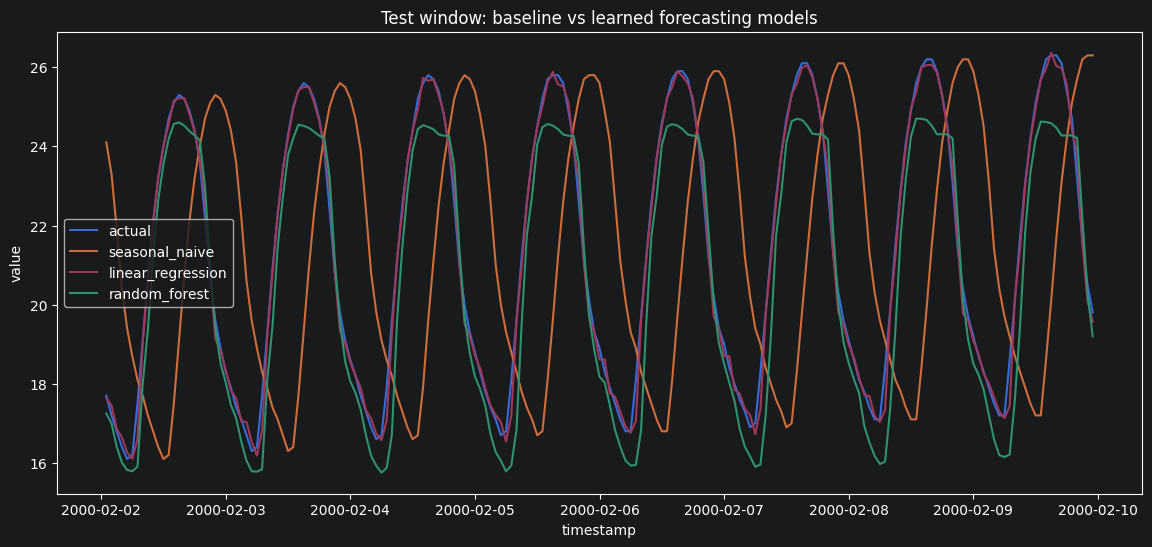

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(plot_df["timestamp"], plot_df["actual"], label="actual")
plt.plot(plot_df["timestamp"], plot_df["seasonal_naive"], label="seasonal_naive")
plt.plot(plot_df["timestamp"], plot_df["linear_regression"], label="linear_regression")
plt.plot(plot_df["timestamp"], plot_df["random_forest"], label="random_forest")
plt.title("Test window: baseline vs learned forecasting models")
plt.xlabel("timestamp")
plt.ylabel("value")
plt.legend()
plt.show()


In [14]:
# TODO: add rolling-origin evaluation
# TODO: extend to multi-step forecasts
# TODO: compare LLM-assisted model selection or feature suggestions later
planned_todos = [
    "add rolling-origin evaluation",
    "extend to multi-step forecasts",
    "compare LLM-assisted model selection or feature suggestions later",
]
print("Planned next steps:")
for t in planned_todos:
    print("-", t)

Planned next steps:
- use real M4 daily data
- add rolling-origin evaluation
- extend to multi-step forecasts
- compare LLM-assisted model selection or feature suggestions later


In [15]:
print("Day 5 completed: compared forecasting models on a one-step-ahead protocol.")


Day 5 completed: compared forecasting models on a one-step-ahead protocol.
